In [1]:
import pandas as pd
import numpy as np
import importlib
from tqdm import tqdm

from sklearn.metrics import silhouette_score

import networkx as nx
import community as community_louvain

import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import utility_functions as uf

In [2]:
df_cs_yearly = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col = [0, 1, 2]).xs("individual", level=2)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

n_years = 5

df_cs_yearly = (
    df_cs_yearly
    .sort_index()
    .groupby(level=0)
    .rolling(n_years).sum()
    .reset_index(level=0, drop=True)
)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

df_dist_yearly = pd.read_csv(uf.PATH+"df_dist_w1_rolling_yearly_individual.csv", index_col=[0, 1])

In [3]:
import geopandas as gpd
import matplotlib.patches as mpatches

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world_url = gpd.read_file(url)

In [4]:
df_map_analysis = pd.read_csv(uf.PATH+"df_map_analysis.csv").dropna(subset="cluster")

In [5]:
df_map_analysis.dropna(subset="cluster")

,year,country,cluster
37,1975,AR,8.0
38,1975,AT,0.0
39,1975,AU,7.0
40,1975,BE,5.0
41,1975,BG,4.0
...,...,...,...
3890,2023,VN,17.0
3891,2023,YE,5.0
3892,2023,ZA,17.0
3893,2023,ZM,18.0


# Utilities

In [6]:
# df_baricenter_yearly_list = []

# year_list = df_map_analysis.year.drop_duplicates().sort_values().to_list()

# for year_loop in tadm(year_list):
#     country_list = df_map_analysis.query("year == @year_loop").country.to_list()
#     df_prob = df_prob_yearly.xs(year_loop, level=1).loc[country_list].fillna(0)
#     df_baricenter_yearly_list.append(uf.get_w1_barycenter(df_prob).T.rename(columns={0: year_loop}))
    
# df_baricenter_global_yearly = pd.concat(df_baricenter_yearly_list, axis=1).T

In [10]:
# df_baricenter_global_yearly.to_csv(uf.PATH+"df_barycenter_global_yearly.csv")
df_baricenter_global_yearly = pd.read_csv(uf.PATH+"df_barycenter_global_yearly.csv", index_col=0)

In [12]:
uf.plotly_heatmap(df_baricenter_global_yearly, df_baricenter_global_yearly.columns, df_baricenter_global_yearly.index,
                  colorscale="non", z_min=0, z_max=0.02, line_height=10, x_type="subfield")

In [13]:
df_std_yearly = (
    df_prob_yearly
    .groupby(level=1)
    .std()
)

In [14]:
cluster_list = df_map_analysis.cluster.drop_duplicates().sort_values().to_list()
subfield_tree = uf.get_subfield_tree(uf.df_topics)

In [ ]:
# profile_yearly_list = []
# for cluster_loop in cluster_list:
#     cluster_year_list = df_map_analysis.query("cluster == @cluster_loop").year.drop_duplicates().sort_values().to_list()
#     cluster_profile_yearly_list = []
#     for year_loop in cluster_year_list:
#         cluster_country_list = df_map_analysis.query("cluster == @cluster_loop and year == @year_loop").country.drop_duplicates().sort_values().to_list()
#         if cluster_country_list == []:
#             print(year_loop, cluster_loop)
#             continue
#         # print(cluster_country_list)
#         df_prob = df_prob_yearly.xs(year_loop, level=1).loc[cluster_country_list].fillna(0)
#         cluster_profile_yearly_list.append(uf.get_w1_barycenter(df_prob).T.rename(columns={0: year_loop}))
#     # print(cluster_profile_yearly_list)
#     if cluster_profile_yearly_list == []:
#         print(year_loop, cluster_loop)
#         continue
#     profile_yearly_list.append(pd.concat(cluster_profile_yearly_list, axis=1).T.assign(cluster=cluster_loop))
# df_profile_yearly = pd.concat(profile_yearly_list).reset_index(names="year").set_index(["cluster", "year"])

In [15]:
# df_profile_yearly.to_csv(uf.PATH+"df_profile_by_cluster.csv")
df_profile_yearly = pd.read_csv(uf.PATH+"df_profile_by_cluster.csv", index_col=[0, 1])

In [16]:
pivot = df_map_analysis.pivot(index="country", columns="year", values="cluster")
pivot

clusters = pivot.values

# Broadcasting comparison
same_cluster = clusters[:, None, :] == clusters[None, :, :]

# Count matches across years
co_membership = same_cluster.sum(axis=2)

# Convert back to dataframe
df_neighbours_counts = pd.DataFrame(
    co_membership,
    index=pivot.index,
    columns=pivot.index
)

# df_n_years = pd.DataFrame(
#     co_membership,
#     index=pivot.index,
#     columns=pivot.index
# )
# df_dist_clusters_yearly = 1 - df_n_years.div(np.diagonal(df_n_years.values))

# # df_dist_clusters_yearly.to_csv(uf.PATH+f"df_dist_countries_{param_value}_medoid_short_w1_{mode}.csv", index=True)

In [17]:
# uf.plotly_heatmap(df_baricenter_global_yearly,
#                   x_labels=df_baricenter_global_yearly.columns,
#                   y_labels=df_baricenter_global_yearly.index,
#                   colorscale="non",
#                   z_min=0, z_max=0.02,
#                   line_height=10,
#                   x_type="subfield")

# Country overview

In [18]:
country = "BR"

year_list = df_map_analysis.query("country == @country").year.drop_duplicates().sort_values().to_list()
country_clusters = df_map_analysis.query("country == @country").cluster.drop_duplicates().sort_values().to_list()

In [19]:
df_profile_country = df_prob_yearly.xs(country, level=0).loc[year_list]

In [20]:
uf.plotly_heatmap(df_profile_country, x_labels=df_profile_country.columns, y_labels=year_list, colorscale="non", z_min=0, z_max=0.02, line_height=10, title=country)

In [21]:
cmap = plt.get_cmap("viridis")

In [22]:
df_gl = (
    df_baricenter_global_yearly
    .loc[year_list]
    .apply(uf.gini, axis=1)
    .to_frame("global")
)
df_cl = (
    df_map_analysis
    .query("country == @country")
    .merge(df_profile_yearly, left_on=["cluster", "year"], right_index=True, how="left")
    .drop(columns=["country", "cluster"])
    .set_index("year")
    .apply(uf.gini, axis=1)
    .to_frame("cluster")
)

df_c = (
    df_profile_country
    .apply(uf.gini, axis=1)
    .to_frame(country)
)

df_gini = pd.concat([df_gl, df_cl, df_c], axis=1)

In [23]:
cluster_list = df_map_analysis.query("country == @country").cluster.drop_duplicates().to_list()
cluster_labels = dict(zip(cluster_list ,["Cluster "+str(cl) if cluster_list[cl-1] != 0 else "Undefined" for cl in range(1, len(cluster_list)+1)]))
cluster_colors = dict(zip(cluster_list, cmap(np.linspace(0, 1, len(cluster_labels)))))

In [24]:
import itertools

year_cluster = dict(zip(df_map_analysis.query("country == @country")[["year", "cluster"]].drop_duplicates().year,
                        df_map_analysis.query("country == @country")[["year", "cluster"]].drop_duplicates().cluster))

segments = []
for cluster, group in itertools.groupby(year_cluster.items(), key=lambda x: x[1]):
    years = [y for y, _ in group]
    segments.append((min(years), max(years), cluster))

In [25]:
import matplotlib.patches as mpatches

cluster_handles = [
    mpatches.Patch(color=color, alpha=0.2, label=cluster)
    for cluster, color in cluster_colors.items()
]

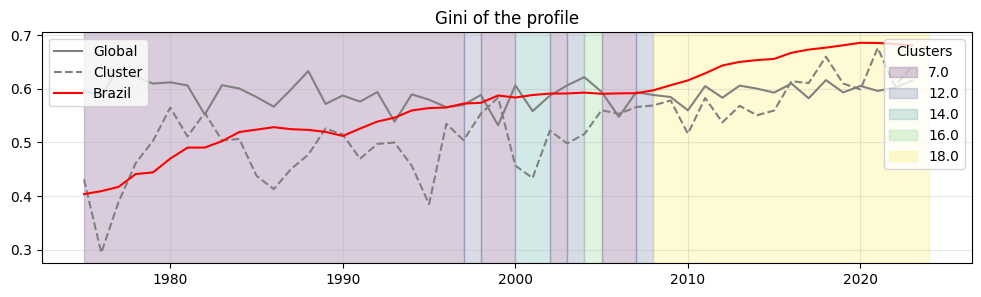

In [26]:
fig, ax = plt.subplots(figsize=(12, 3))

# --- background shading ---
for start, end, cluster in segments:
    ax.axvspan(
        start,
        end + 1,
        color=cluster_colors[cluster],
        alpha=0.2
    )

# --- lines ---
line1, = ax.plot(df_gl.index, df_gl.values, label="Global", color="grey")
line2, = ax.plot(df_cl.index, df_cl.values, label="Cluster", color="grey", linestyle="--")
line3, = ax.plot(df_c.index, df_c.values, label=uf.id2name_country[country], color="red")

# --- legends ---
line_legend = ax.legend(loc="upper left")   # for lines
ax.add_artist(line_legend)                 # keep it

cluster_legend = ax.legend(
    handles=cluster_handles,
    title="Clusters",
    loc="upper right"
)

ax.grid(alpha=0.3)
_ = ax.set_title("Gini of the profile")

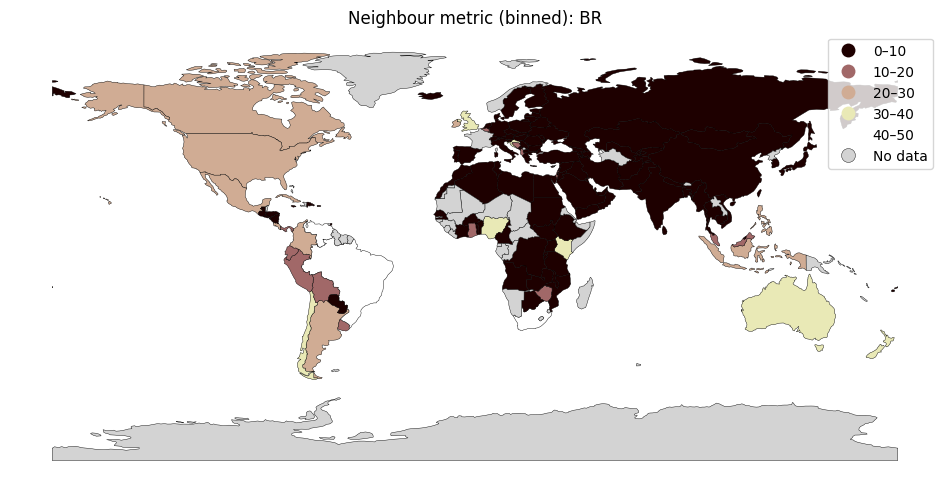

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Define bins ---
bins = [0, 10, 20, 30, 40, 50]
labels = [f"{bins[i]}–{bins[i+1]}" for i in range(len(bins) - 1)]

# --- 2. Prepare data ---
df_plot_neighbours = (
    df_neighbours_counts
    .loc[country]
    .sort_values(ascending=False)
    .to_frame("years")
    .merge(
        uf.df_country[["alpha-2", "alpha-3"]],
        left_index=True,
        right_on="alpha-2",
        how="left"
    )
)

# --- 3. Create categorical variable ---
df_plot_neighbours["years_category"] = pd.cut(
    df_plot_neighbours["years"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# --- 4. Merge with world map ---
world = world_url.merge(
    df_plot_neighbours,
    left_on="ISO_A3",
    right_on="alpha-3",
    how="left"
)

# --- 5. Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

world.plot(
    column="years_category",   # categorical column
    cmap="pink",            # automatically applied
    legend=True,               # clean legend
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

# --- 6. Styling ---
ax.set_axis_off()
ax.set_title(f"Neighbour metric (binned): {country}")

plt.show()

# Cluster overview

In [45]:
cluster = 18
# 5, 17, 18

In [46]:
years_list = df_map_analysis.query("cluster == @cluster").year.drop_duplicates().sort_values().to_list()
years_list_full = range(years_list[0], years_list[-1]+1)

In [47]:
df_years = pd.DataFrame({}, index=years_list_full)
df_years.loc[years_list] = 1

In [48]:
total_countries = len(pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col = [0, 1, 2]).xs((2023, "individual"), level=[1, 2]).index)

df_pct_country = (
    pd.concat([
        df_map_analysis.query("year == @years_list and cluster == @cluster").groupby("year").country.count().to_frame("cluster"),
        df_map_analysis.query("year == @years_list").groupby("year").country.count().to_frame("all")
    ], axis=1)
    .assign(
        share_cluster = lambda df: df.cluster / total_countries,
        share_other = lambda df: (df.eval("all - cluster")) / total_countries)
)
# df_pct_country

In [49]:
df_pct_articles = (
    df_cs_yearly
    .merge(df_map_analysis.query("cluster == @cluster"), left_index=True, right_on=["country", "year"])
    .drop(columns=["country", "cluster"])
    .groupby(["year"])
    .sum()
    .sum(axis=1)
    .to_frame("share_cluster")
    .div(df_cs_yearly.sum(axis=1).groupby(level=1).sum().loc[years_list], axis=0)
    .assign(share_other = lambda df: 1 - df.share_cluster)
)
# df_pct_articles

In [50]:
bins = [0, 0.10, 0.50, 0.90, 1]
labels = [f"{int(bins[i]*100)}–{int(bins[i+1]*100)}%" for i in range(len(bins) - 1)]

df_cluster_country_count = (
    df_map_analysis
    .query("cluster == @cluster")
    .groupby("country", as_index=False)
    .year
    .count()
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2", how="left")
    .assign(
        year_share = lambda df: df.year / len(years_list),
        year_cat = lambda df: pd.cut(
                                    df["year_share"],
                                    bins=bins,
                                    labels=labels,
                                    include_lowest=True
                                )
    )
)
# df_cluster_country_count

In [51]:
df_gini_profiles = pd.concat([
    df_baricenter_global_yearly.loc[years_list].apply(uf.gini, axis=1).to_frame("all"),
    df_profile_yearly.xs(cluster, level=0).apply(uf.gini, axis=1).to_frame("cluster")
], axis=1)

In [52]:
df_gini_countries = pd.concat([(
    df_cs_yearly.sum(axis=1).to_frame("total")
    .merge(df_map_analysis.query("cluster == @cluster"), left_index=True, right_on=["country", "year"], how="right")
    .groupby("year")
    .total
    .agg(uf.gini)
    .to_frame("cluster")
), df_cs_yearly.sum(axis=1).groupby(level=1).agg(uf.gini).to_frame("all").loc[years_list]], axis=1)

In [53]:
df_domains = (
    df_profile_yearly
    .xs(cluster, level=0)
    .T
    .merge(uf.df_topics[["subfield_id", "domain_name"]].drop_duplicates().assign(subfield_id_str=lambda df: df.subfield_id.astype(str)),
           left_index=True, right_on="subfield_id_str")
    .drop(columns=["subfield_id", "subfield_id_str"])
    .groupby("domain_name")
    .sum()
    .T
    # .sum()
)

In [54]:
df_spec = (
    df_profile_yearly.xs(cluster, level=0)
    .sub(df_baricenter_global_yearly.loc[years_list])
    # .div(df_std_yearly.T.loc[df_baricenter_global_yearly.columns].T.loc[years_list])
)

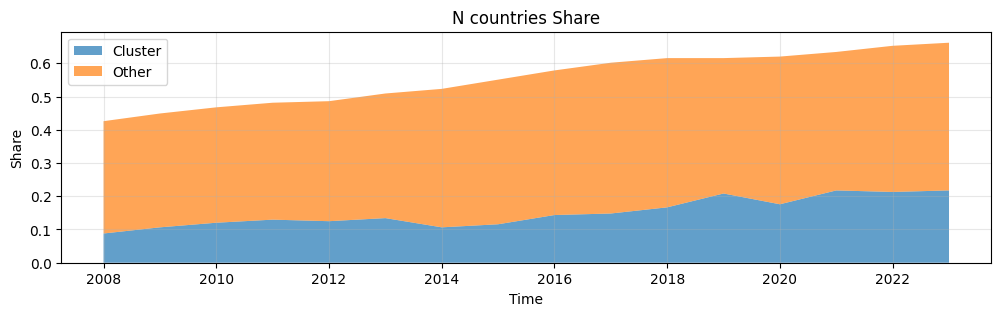

In [55]:
fig, ax = plt.subplots(figsize=(12, 3))

x = df_pct_country.index
y1 = df_pct_country["share_cluster"]
y2 = df_pct_country["share_other"]

ax.stackplot(x, y1, y2, labels=["Cluster", "Other"], alpha=0.7)

ax.legend(loc="upper left")
ax.set_ylabel("Share")
ax.set_xlabel("Time")
ax.set_title("N countries Share")
plt.grid(alpha=0.3)

plt.show()

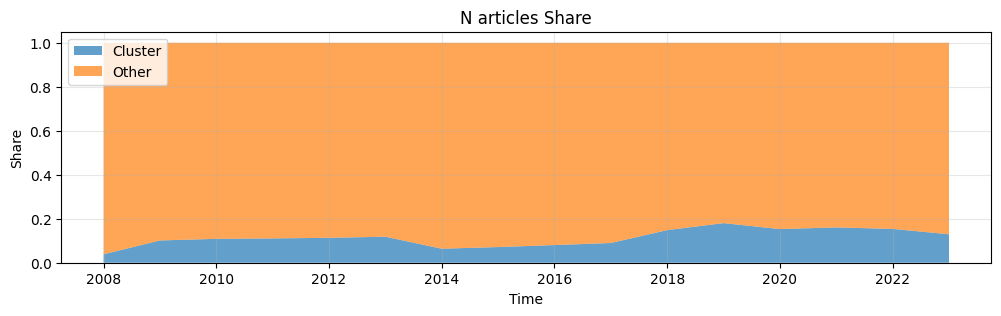

In [56]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3))

x = df_pct_articles.index
y1 = df_pct_articles["share_cluster"]
y2 = df_pct_articles["share_other"]

ax.stackplot(x, y1, y2, labels=["Cluster", "Other"], alpha=0.7)

ax.legend(loc="upper left")
ax.set_ylabel("Share")
ax.set_xlabel("Time")
ax.set_title("N articles Share")
plt.grid(alpha=0.3)

plt.show()

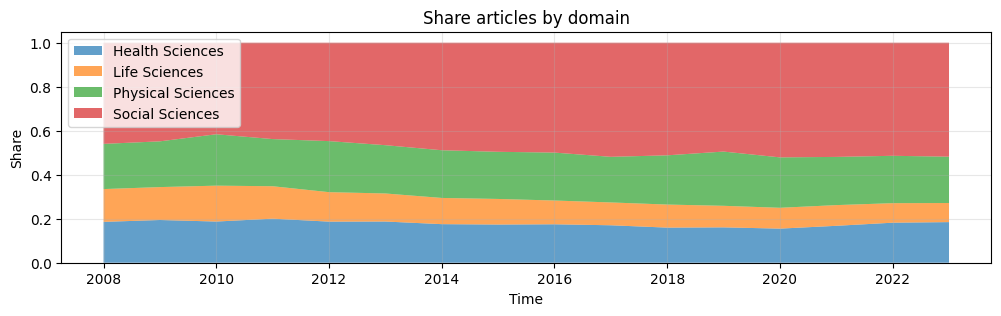

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3))

x = df_domains.index.astype(int)
y1 = df_domains[df_domains.columns[0]]
y2 = df_domains[df_domains.columns[1]]
y3 = df_domains[df_domains.columns[2]]
y4 = df_domains[df_domains.columns[3]]

ax.stackplot(x, y1, y2, y3, y4, labels=df_domains.columns, alpha=0.7)

ax.legend(loc="upper left")
ax.set_ylabel("Share")
ax.set_xlabel("Time")
ax.set_title("Share articles by domain")
plt.grid(alpha=0.3)

plt.show()

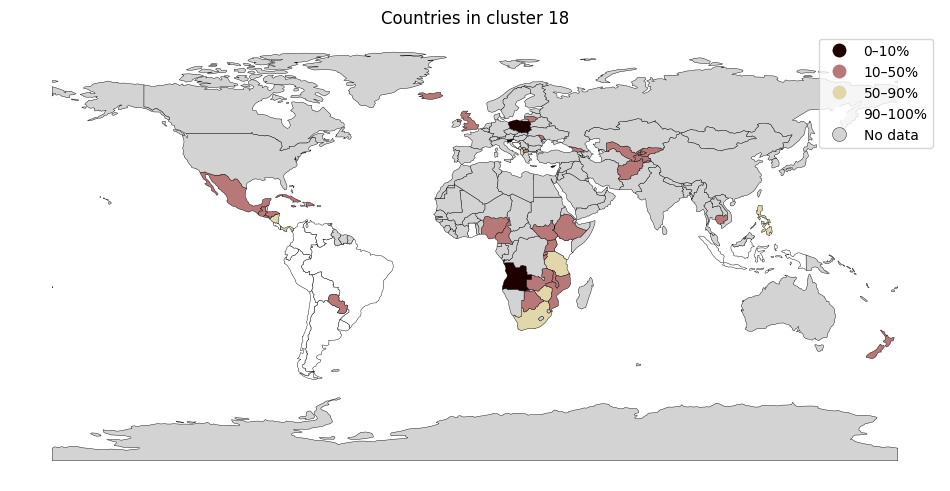

In [58]:
import pandas as pd
import matplotlib.pyplot as plt


# --- 4. Merge with world map ---
world = world_url.merge(
    df_cluster_country_count,
    left_on="ISO_A3",
    right_on="alpha-3",
    how="left"
)

# --- 5. Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

world.plot(
    column="year_cat",   # categorical column
    cmap="pink",            # automatically applied
    legend=True,               # clean legend
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

# --- 6. Styling ---
ax.set_axis_off()
ax.set_title(f"Countries in cluster {cluster}")

plt.show()

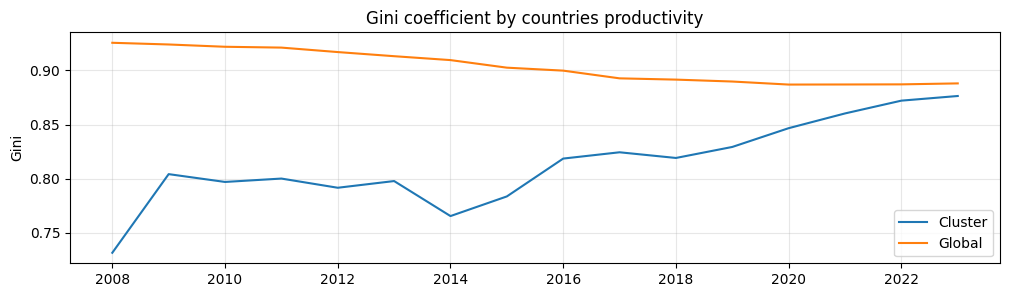

In [59]:
fig, ax = plt.subplots(figsize=(12, 3))
plt.plot(df_gini_countries.index, df_gini_countries.cluster, label="Cluster")
plt.plot(df_gini_countries.index, df_gini_countries["all"], label="Global")
plt.grid(alpha=0.3)
plt.ylabel("Gini")
plt.legend()
_ = plt.title("Gini coefficient by countries productivity")

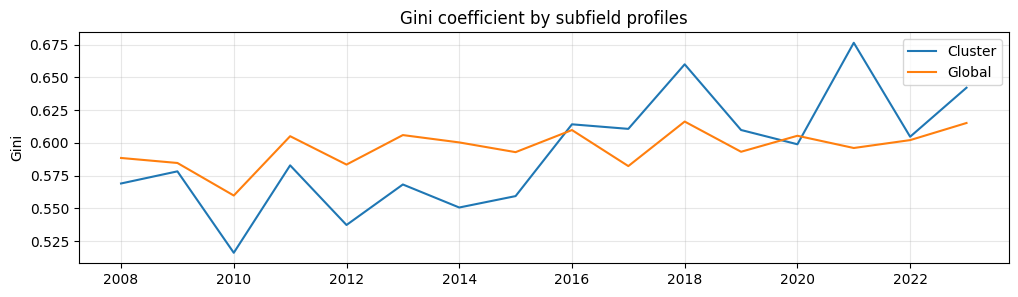

In [60]:
fig, ax = plt.subplots(figsize=(12, 3))
plt.plot(df_gini_profiles.index, df_gini_profiles.cluster, label="Cluster")
plt.plot(df_gini_profiles.index, df_gini_profiles["all"], label="Global")
plt.grid(alpha=0.3)
plt.ylabel("Gini")
plt.legend()
_ = plt.title("Gini coefficient by subfield profiles")

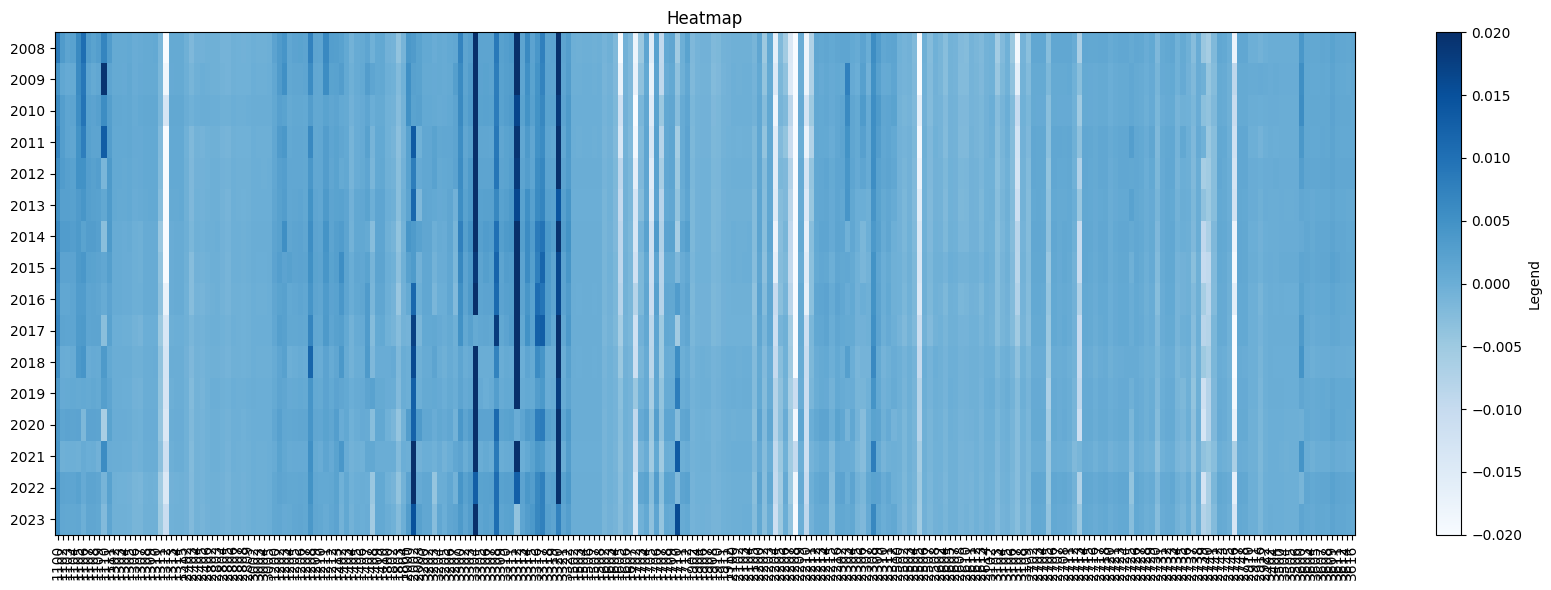

In [61]:
uf.plot_heatmap(df_spec, df_spec.columns, df_spec.index, line_height=10,
                # x_type="subfield",
                z_min=-0.02, z_max=0.02)

# Year overview